In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# System Identification Function
def identify_lti_system_ols(X, U):
    X_t = X[:, :-1]
    X_t1 = X[:, 1:]
    U_t = U
    Phi = np.vstack((X_t, U_t))
    Theta = X_t1 @ np.linalg.pinv(Phi)
    n = X.shape[0]
    m = U.shape[0]
    A_est = Theta[:, :n]
    B_est = Theta[:, n:]
    return A_est, B_est

# Finite-Horizon LQR Function
def finite_horizon_lqr(A, B, Q, R, Q_f, T):
    n, m = B.shape
    P_list = [None] * (T + 1)
    K_list = [None] * T
    P_list[T] = Q_f
    for t in range(T - 1, -1, -1):
        P_next = P_list[t + 1]
        K_t = np.linalg.inv(R + B.T @ P_next @ B) @ (B.T @ P_next @ A)
        P_t = Q + A.T @ P_next @ (A - B @ K_t)
        K_list[t] = K_t
        P_list[t] = P_t
    return K_list, P_list

# Simulation Function
def simulate_finite_horizon_lqr(A, B, K_list, x0, T):
    n, m = B.shape
    X = np.zeros((n, T + 1))
    U = np.zeros((m, T))
    X[:, [0]] = x0
    for t in range(T):
        U[:, [t]] = -K_list[t] @ X[:, [t]]
        X[:, [t + 1]] = A @ X[:, [t]] + B @ U[:, [t]]
    return X, U

# Generate System Data
def generate_lti_data_with_noise(A, B, x0, U, timesteps, noise_level):
    n, m = B.shape
    X = np.zeros((n, timesteps + 1))
    X[:, [0]] = x0
    for k in range(timesteps):
        w_t = np.random.normal(0, noise_level, size=(n, 1))
        X[:, [k + 1]] = A @ X[:, [k]] + B @ U[:, [k]] + w_t
    return X, U


# MSE Calculation Function
def calculate_mse(U_true, U_est):
    return np.mean((U_true - U_est) ** 2)


In [3]:
# Configuration Dictionary
config = {
    "A_true": np.array([[0.9, 0.1], [-0.2, 0.8]]),  # True system matrix A
    "B_true": np.array([[0.1], [0.3]]),             # True input matrix B
    "Q": np.array([[1.0, 0.0], [0.0, 1.0]]),       # State cost matrix Q
    "R": np.array([[0.1]]),                        # Control cost matrix R
    "Q_f": np.array([[10.0, 0.0], [0.0, 10.0]]),   # Terminal cost matrix Q_f
    "T": 20,                                       # Time horizon
    "x0": np.array([[1.0], [0.0]]),               # Initial state
    "timesteps": 100,                              # Timesteps for system identification
    "noise_level": 0.5                            # Noise level in data generation
}

True A:
 [[ 0.9  0.1]
 [-0.2  0.8]]
Estimated A:
 [[ 0.83463995  0.08334917]
 [-0.18562208  0.81082739]]
True B:
 [[0.1]
 [0.3]]
Estimated B:
 [[0.05161299]
 [0.30168304]]
Mean Squared Error of Control Inputs: 0.040579


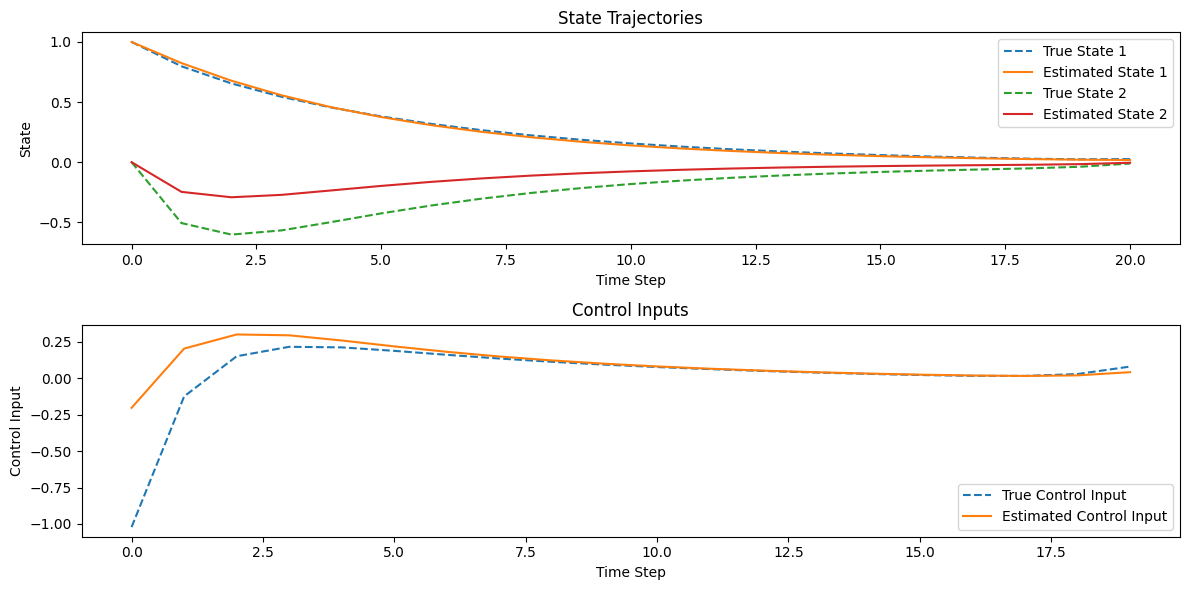

In [4]:

# Main Code
if __name__ == "__main__":
    # Extract parameters from the config
    A_true = config["A_true"]
    B_true = config["B_true"]
    Q = config["Q"]
    R = config["R"]
    Q_f = config["Q_f"]
    T = config["T"]
    x0 = config["x0"]
    timesteps = config["timesteps"]
    noise_level = config["noise_level"]

    # Generate system data
    U_data = np.random.randn(1, timesteps)
    X_data, U_data = generate_lti_data_with_noise(A_true, B_true, x0, U_data, timesteps, noise_level)

    # Identify system matrices
    A_est, B_est = identify_lti_system_ols(X_data, U_data)
    print("True A:\n", A_true)
    print("Estimated A:\n", A_est)
    print("True B:\n", B_true)
    print("Estimated B:\n", B_est)

    # Compute LQR for true system
    K_true, _ = finite_horizon_lqr(A_true, B_true, Q, R, Q_f, T)
    X_true, U_true = simulate_finite_horizon_lqr(A_true, B_true, K_true, x0, T)

    # Compute LQR for estimated system
    K_est, _ = finite_horizon_lqr(A_est, B_est, Q, R, Q_f, T)
    X_est, U_est = simulate_finite_horizon_lqr(A_est, B_est, K_est, x0, T)

    # Calculate MSE of control inputs
    mse_control = calculate_mse(U_true, U_est)
    print(f"Mean Squared Error of Control Inputs: {mse_control:.6f}")

    # Plot results
    plt.figure(figsize=(12, 6))

    # Plot state trajectories
    plt.subplot(2, 1, 1)
    plt.plot(X_true[0, :], label="True State 1", linestyle='--')
    plt.plot(X_est[0, :], label="Estimated State 1")
    plt.plot(X_true[1, :], label="True State 2", linestyle='--')
    plt.plot(X_est[1, :], label="Estimated State 2")
    plt.title("State Trajectories")
    plt.xlabel("Time Step")
    plt.ylabel("State")
    plt.legend()

    # Plot control inputs
    plt.subplot(2, 1, 2)
    plt.plot(U_true[0, :], label="True Control Input", linestyle='--')
    plt.plot(U_est[0, :], label="Estimated Control Input")
    plt.title("Control Inputs")
    plt.xlabel("Time Step")
    plt.ylabel("Control Input")
    plt.legend()

    plt.tight_layout()
    plt.show()